## 📊 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the characteristics of the dataset through statistical summaries and visualizations.

The insights gained in this notebook will guide feature engineering and model development.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from src.config import TRAIN_CLEAN_PATH

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
df = pd.read_csv(TRAIN_CLEAN_PATH)

In [4]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [14]:
df_clean["trip_duration"].describe()

count    1.457946e+06
mean     9.587431e+02
std      5.236956e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

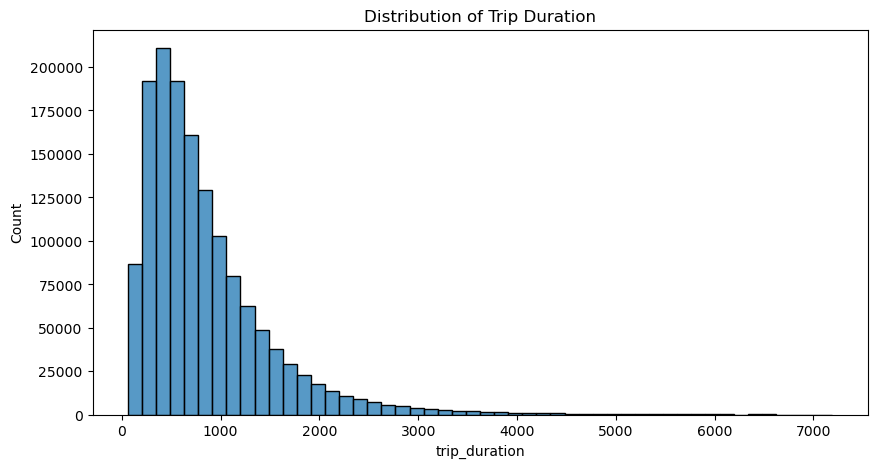

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(df["trip_duration"], bins=50)

plt.title("Distribution of Trip Duration")

plt.show()

- The distribution of trip duration is positively skewed, with most trips lasting for a relatively short time.
- A small number of trips have exceptionally long durations, indicating the presence of outliers.
- Applying a logarithmic transformation or outlier treatment may improve model performance.

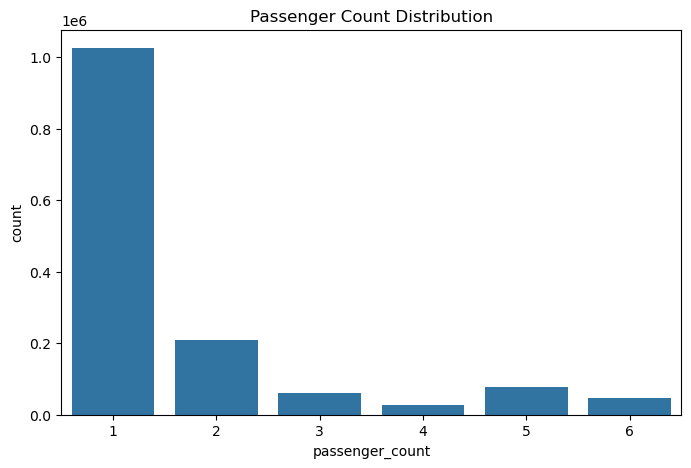

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(x="passenger_count", data=df)

plt.title("Passenger Count Distribution")

plt.show()

- Most taxi trips involve a single passenger, followed by two passengers.
- Trips with more than four passengers are relatively uncommon.
- Passenger count may have limited predictive power but should still be retained as a feature.

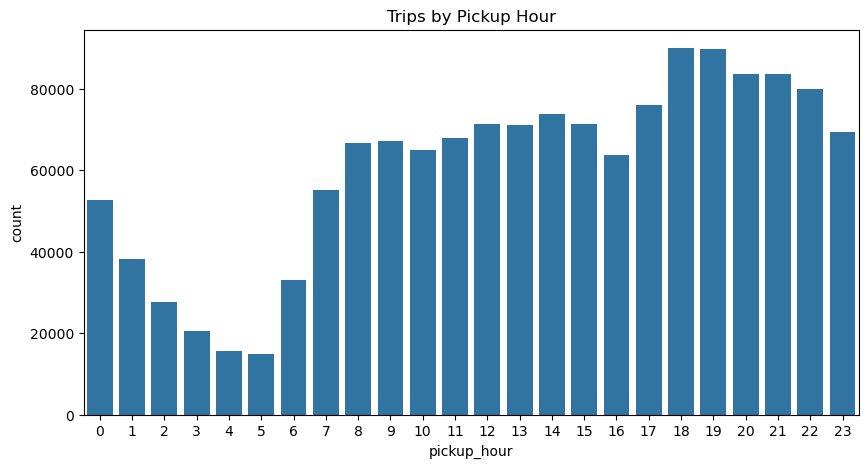

In [9]:
# Pickup hour

df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

df["pickup_hour"] = df["pickup_datetime"].dt.hour

plt.figure(figsize=(10,5))

sns.countplot(x="pickup_hour", data=df)

plt.title("Trips by Pickup Hour")

plt.show()

- Taxi demand varies significantly throughout the day.
- Peak activity occurs during commuting hours, reflecting typical work-related travel patterns.
- Pickup hour is expected to be an important predictor because traffic conditions change throughout the day.

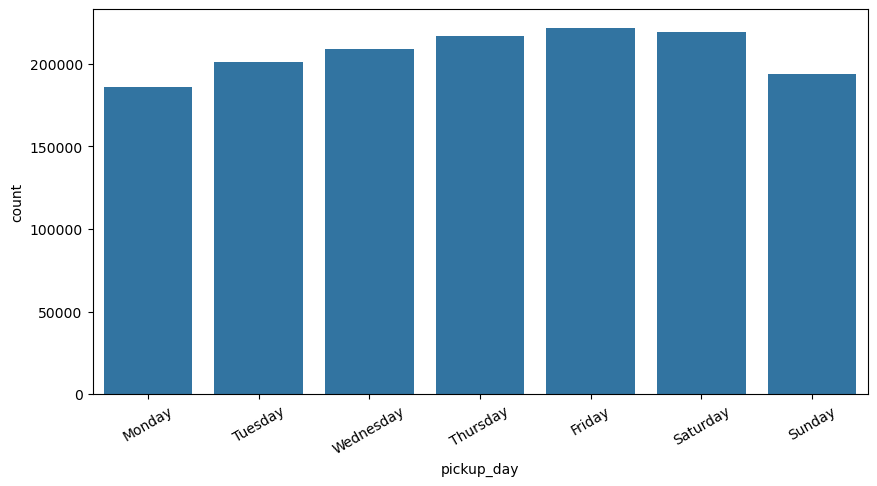

In [10]:
# Pickup Day
df["pickup_day"] = df["pickup_datetime"].dt.day_name()

order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="pickup_day",
    order=order
)

plt.xticks(rotation=30)

plt.show()

- Trip frequency differs across weekdays.
- Weekdays generally experience higher demand than weekends, reflecting business and commuting activities.
- Day of the week is likely to capture recurring temporal patterns useful for prediction.

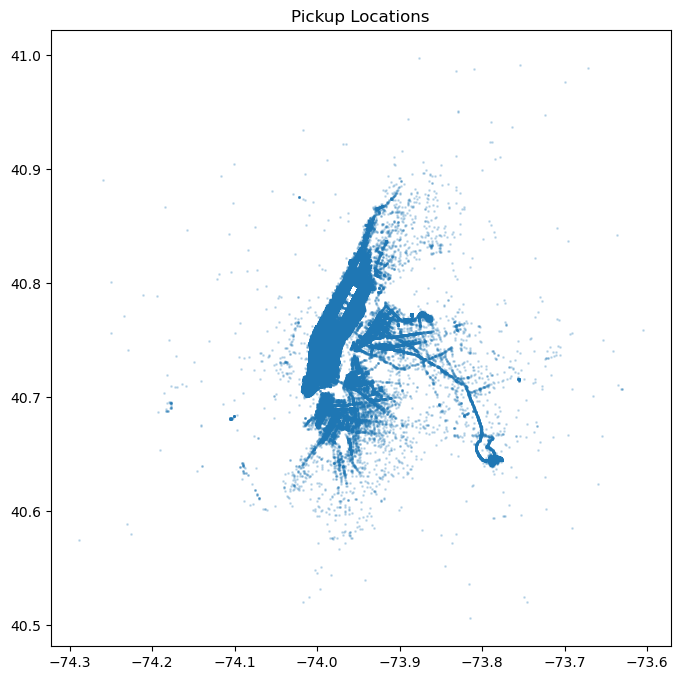

In [12]:
# pickpu location

plt.figure(figsize=(8,8))

plt.scatter(
    df["pickup_longitude"],
    df["pickup_latitude"],
    s=1,
    alpha=0.2
)

plt.title("Pickup Locations")

plt.show()

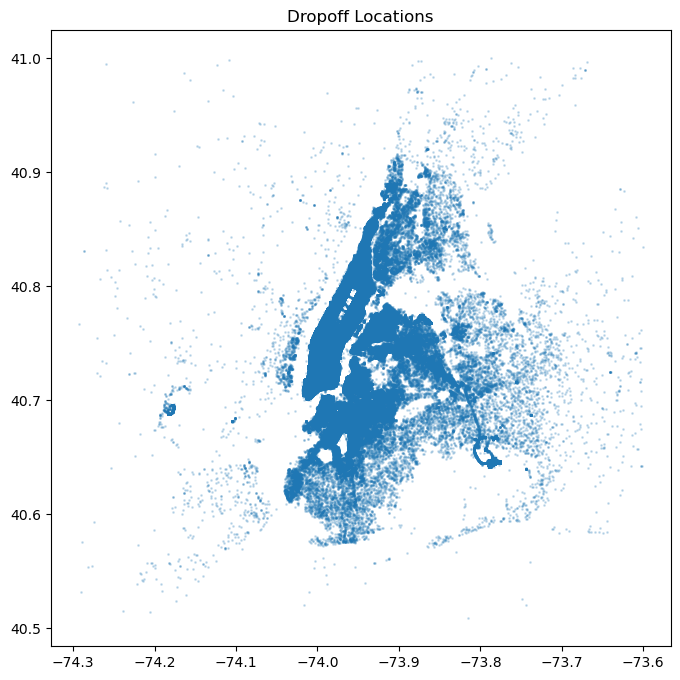

In [13]:
# dropoff location

plt.figure(figsize=(8,8))

plt.scatter(
    df["dropoff_longitude"],
    df["dropoff_latitude"],
    s=1,
    alpha=0.2
)

plt.title("Dropoff Locations")

plt.show()

- Locations are highly concentrated in Manhattan and surrounding urban areas.
- Very few trips originate outside the main city regions.

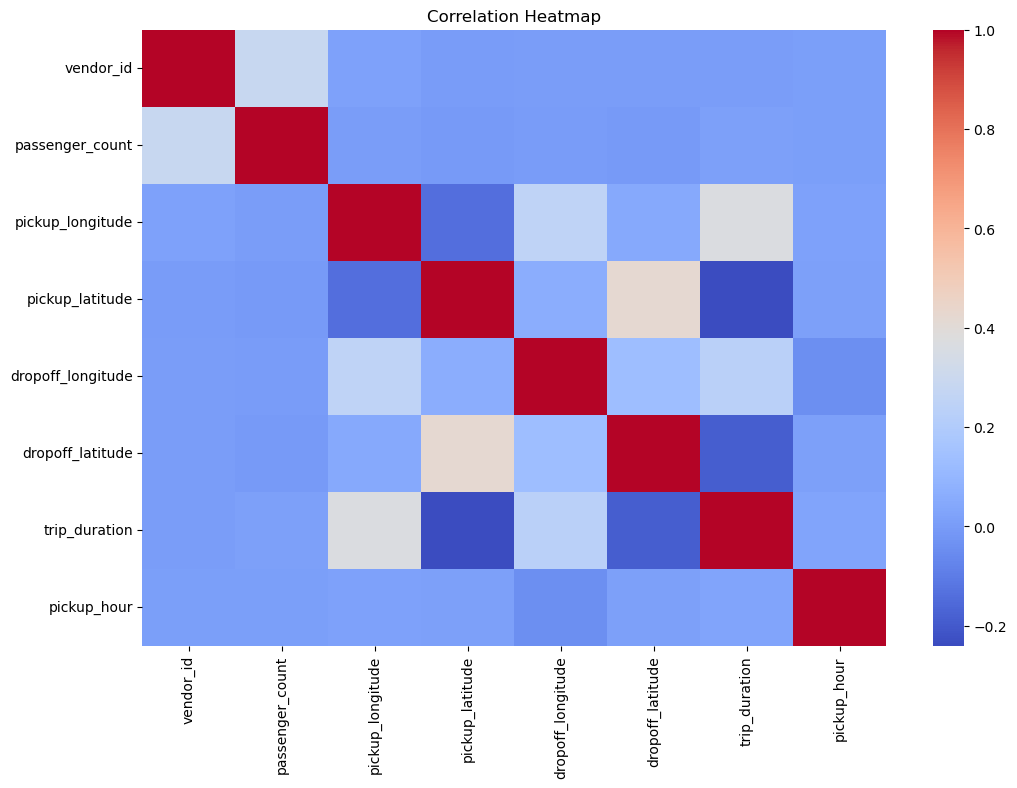

In [14]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

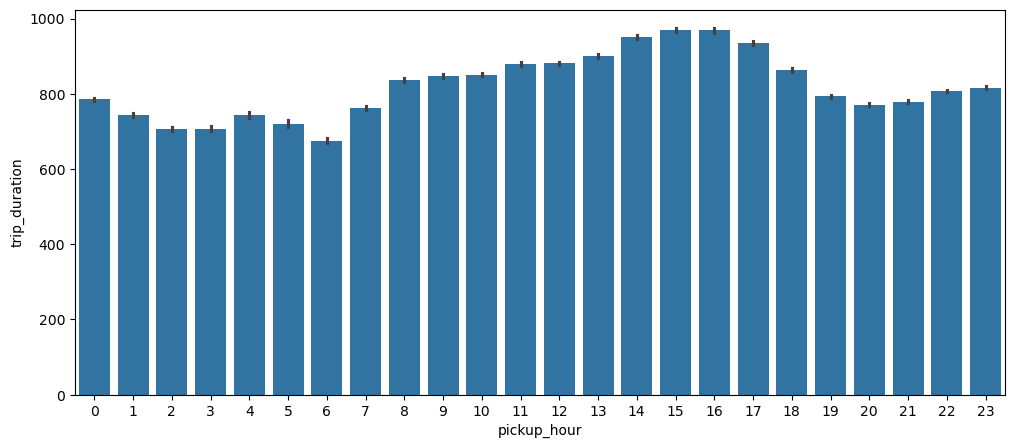

In [19]:
plt.figure(figsize=(12,5))

sns.barplot(
    x="pickup_hour",
    y="trip_duration",
    data=df
)

plt.show()

- Longer trips tend to occur during peak traffic periods, likely due to congestion.

## 🔍 Key Insights

- The target variable is positively skewed with a small number of extreme values.
- Taxi demand varies significantly across different hours and days.
- Geographic coordinates reveal strong clustering around Manhattan.
- Passenger count shows limited influence on trip duration.
- Temporal and spatial features appear to be the most informative variables.
- Feature engineering, particularly distance and time-based features, is expected to significantly improve model performance.